# ERP extension of the macroscopic linear VAR model: drive vs. connectivity

**Exploratory analysis for the event-related extension of Steeghs-Turchina et al. (2025).**

Steeghs-Turchina et al. (2025, *NeuroImage* 321:121418) showed that resting-state
scalp-EEG band features (notably the 8–13 Hz alpha rhythm and its coherence) can
emerge from a *purely macroscopic*, linear vector-autoregressive (VAR) model of
long-range axonal conduction delays, with **no local oscillators** and **no
external input** — all local activity is treated as zero-mean stochastic noise.

This notebook develops the **event-related potential (ERP)** extension. The
resting model already contains a deterministic external-input term
$z(w,t)$ (Eq. 6–11 of the paper) that was set to zero for resting state. Two
biophysically distinct knobs are available for modelling a stimulus:

1. **Additive drive** — a deterministic waveform $z(w,t)$ injected into one or
   more regions (sensory volley / thalamic relay input).
2. **Connectivity modulation** — a transient, multiplicative change of the
   effective coupling tensor $\Phi$ (state- or attention-dependent gain /
   routing change).

The central claim we establish, both analytically and empirically, is:

> **In a zero-mean, stationary, linear model, connectivity modulation *alone*
> cannot generate an ERP. A time-locked, signed deflection such as the P300
> requires an additive drive.** Connectivity modulation can only *gate* the
> amplitude/latency/variability of a drive-generated ERP — it changes the
> second-order structure (variance, power, coherence), never the first-order
> structure (the trial-averaged signed mean).

We make this rigorous, demonstrate it across three experiments
(drive-only, connectivity-only, drive+connectivity), quantify it with a
convergence analysis and the same statistical procedure used in the parent
paper, and discuss the supporting literature and the implications for the
planned nonlinear extension.

> Run from the repository root or from `scripts/`. Plotting requires the
> optional visualisation stack (`poetry install --with viz`).

In [1]:
import os
import sys
import tempfile
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src" / "diaxcondel").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "diaxcondel-mplconfig"))
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from diaxcondel.connectome.atlases.manual import (
    steeghs_2025_distances,
    steeghs_2025_regions,
    steeghs_2025_weights,
)
from diaxcondel.erp import (
    ERPEvent,
    StepModulation,
    baseline_correct,
    peak_amplitude,
    peak_latency,
)
from diaxcondel.kernels.gev import GEVDiameter
from diaxcondel.kernels.invgev import InvGEVKernel
from diaxcondel.model.build import build_linear_var
from diaxcondel.model.params import SimulationParams
from diaxcondel.model.stability import spectral_radius
from diaxcondel.model.var import LinearVAR
from diaxcondel.simulate import GaussianPulseDrive, DriveTarget, get_noise_fn, simulate_trials

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
warnings.simplefilter("default")
RNG_SEED = 20260516

## 1. What is an ERP, and why is the model class the crux?

An **event-related potential** is the part of the EEG that is **time-locked and
phase-locked** to a repeated event. It is operationally *defined* by
**signal averaging**: across $N$ stimulus-aligned trials the ongoing,
event-unrelated activity (treated here as zero-mean noise) averages towards
zero while a deterministic, stimulus-locked component survives. The
signal-to-noise ratio of the average grows as $\sqrt{N}$
(Luck, 2014, *An Introduction to the ERP Technique*, 2nd ed., MIT Press).
Canonical components such as the **P300** (a positive parietal deflection
~300–600 ms after task-relevant stimuli; Polich, 2007,
*Clin. Neurophysiol.* 118:2128) are, by construction, **signed, non-zero-mean
deflections of the trial average**.

The model of the parent paper is, after the linear approximation
($\alpha(u)\to 0$, Eq. 2) and treating local activity as noise (Eq. 6):

$$
h(w,t) \;=\; \underbrace{z(w,t)}_{\text{deterministic drive}}
\;+\; \sum_{n=1}^{N}\sum_{p=1}^{P}\,
\underbrace{\ell(u_n,w,t{-}p\Delta t)\,\gamma(u_n,w)}_{\Phi_p[w,u_n]}\;
h(u_n,t{-}p\Delta t)
\;+\; \underbrace{\epsilon(w,t)}_{\text{zero-mean noise}} .
$$

Two facts about this equation decide everything that follows:

* it is **linear** in the state $h$, and
* the parent paper **requires the VAR to be stationary** — the companion
  matrix eigenvalues must lie strictly inside the unit circle; if not, the
  weights are shrunk $\gamma \leftarrow 0.9\,\gamma$ until they do
  (Eqs. 24–25; Shumway & Stoffer, 2017).

Section 3 shows that these two facts *alone* forbid a connectivity-only ERP.

## 2. Reference five-region model

We reuse the validated resting-state construction: the five broad regions
(frontal `FL`, parietal `PL`, occipital `OL`, temporal `TL`, thalamus `T`),
streamline-length distances, custom resting-state weights, and the inverse-GEV
delay kernel. Stationarity is enforced exactly as in the paper (the shrink
warning is informative and is **not** suppressed).

To keep this exploratory notebook responsive we sample at 250 Hz with a
75-lag model (300 ms of delay coverage — the same physical horizon as the
paper's 300 lags at 1 kHz). Burn-in (100 samples) exceeds the lag depth so the
VAR start-up transient is fully absorbed before $t=0$.

In [3]:
regions = steeghs_2025_regions()
distances = steeghs_2025_distances()
weights = steeghs_2025_weights()

params = SimulationParams(
    sample_rate_hz=250,
    sim_seconds=1.2,
    burnin_seconds=0.4,
    n_lags=75,
)

diameter = GEVDiameter(mu=0.25, sigma=0.09, xi=-0.25)
kernel = InvGEVKernel(diameter=diameter, speed_factor=6.0)

base_model = build_linear_var(distances, weights, kernel, params, enforce_stationarity=True)

# The paper's shrink stops as soon as the spectral radius drops below 1, so the
# base model sits right at the stationarity boundary (rho ~ 0.99). To study an
# *amplifying* connectivity modulation while remaining strictly stationary we
# take a little extra coupling headroom (an additional uniform shrink). This is
# the same operation the paper applies for stationarity (Eq. 25), only with a
# slightly larger margin; it does not change the model class.
HEADROOM = 0.75
model = LinearVAR(phi=base_model.phi * HEADROOM)

companion = model.companion_matrix()
print("regions          :", regions.codes)
print("Phi shape (P,N,N):", model.phi.shape)
print("spectral radius  :", round(spectral_radius(companion), 4),
      f"(< 1: stationary; extra headroom factor = {HEADROOM})")

regions          : ('FL', 'PL', 'OL', 'TL', 'T')
Phi shape (P,N,N): (75, 5, 5)
spectral radius  : 0.9771 (< 1: stationary; extra headroom factor = 0.75)


/var/folders/j2/mbj9r8ps7730d3m6nysbkjkc0000gn/T/ipykernel_7063/3051710394.py:15: UserWarning: shrank phi 7 times to reach stationarity (effective coupling reduced by factor 0.4783); consider reducing connectivity weights or speed_factor
  base_model = build_linear_var(distances, weights, kernel, params, enforce_stationarity=True)


**Stimulus design.** A brief Gaussian pulse models a sensory volley arriving in
the occipital lobe (`OL`); the *network impulse response*, not the input shape,
sculpts the scalp ERP morphology. Following ERP practice we keep the per-trial
SNR low (the response is buried in single trials and only emerges after
averaging — exactly the situation that makes averaging necessary; Luck, 2014).

* onset 0.30 s post-stimulus (relative to the analysis window),
* baseline window `(0.00, 0.25) s`, post-stimulus component window
  `(0.30, 0.60) s` (the P300-analogue interval),
* white background noise (the paper's simulation #1 colour).

In [4]:
TARGET = "OL"
target_idx = regions.index(TARGET)

ONSET_S = 0.30
BASELINE_WIN = (0.00, 0.25)
COMPONENT_WIN = (0.30, 0.60)

noise_fn = get_noise_fn("white", std=0.02)

drive = GaussianPulseDrive(
    duration_seconds=0.10,
    peak_seconds=0.03,
    width_seconds=0.012,
    amplitude=5.0,
    targets=(DriveTarget(TARGET, weight=1.0),),
)

# Transient gain increase on the parietal-occipital and fronto-occipital
# pathways (the paper's strongest alpha-relevant edges), 250 ms duration.
# instability_policy="ignore" skips only the per-sample stationarity *check*
# (a full companion-eigendecomposition that is prohibitively slow inside the
# trial loops); it does NOT change the dynamics. We instead verify stationarity
# once, explicitly, in the dedicated cell below.
factor = np.ones((len(regions), len(regions)))
for src, dst in [("PL", "OL"), ("OL", "PL"), ("FL", "OL"), ("OL", "FL")]:
    factor[regions.index(dst), regions.index(src)] = 1.6
modulation = StepModulation(factor=factor, duration_seconds=0.25, instability_policy="ignore")

N_TRIALS = 120
print("single-sample background-noise std :", round(0.02 * np.sqrt(params.sample_rate_hz), 3))
print("component window samples           :",
      int(COMPONENT_WIN[0] * params.sample_rate_hz), "..",
      int(COMPONENT_WIN[1] * params.sample_rate_hz))

single-sample background-noise std : 0.316
component window samples           : 75 .. 150


## 3. Theory: a zero-mean stationary linear model has a zero ERP without a drive

Let the noise be zero-mean, $\mathbb{E}[\epsilon(t)] = 0$, and let the coupling
be an arbitrary **deterministic** (possibly time-varying) sequence $\Phi_t$ — a
connectivity modulation is exactly such a deterministic schedule. Take
expectations over noise realisations of the model equation **with no drive**
($z\equiv 0$) and write $m(t)=\mathbb{E}[h(t)]$:

$$
m(t) \;=\; \sum_{p=1}^{P}\Phi_t(p)\, m(t-p) \;+\; \mathbb{E}[\epsilon(t)]
      \;=\; \sum_{p=1}^{P}\Phi_t(p)\, m(t-p).
$$

Before the stimulus the system is at its stationary distribution, so
$m(t)=0$ for the pre-stimulus lags. The recursion is **homogeneous** (no
forcing term), hence by induction $m(t)=0$ for **all** $t$, *for any
deterministic $\Phi_t$ schedule whatsoever*. **The trial-averaged signal is
identically zero unless a deterministic additive drive $z$ is present.**

Two consequences:

* **Connectivity modulation moves only the second moment.** It changes
  $\mathrm{Var}[h(t)]$, the PSD and coherence (it multiplies a zero-mean
  process), but the first moment — the ERP — stays pinned at zero. Empirically
  the trial average does not converge to a waveform; it stays at the sampling
  floor $\sim \sigma/\sqrt{N}\to 0$.
* **Stationarity forbids "riding the weights".** One might hope to *bias* the
  mean by pushing $\Phi$ far enough. But the paper's model must stay
  stationary (spectral radius $<1$; Eqs. 24–25). A modulation strong/long
  enough to bias the state would push the companion spectral radius
  $\ge 1$ → non-stationary → *unbounded variance*, not a clean,
  reproducible P300-shaped peak. And because the only thing $\Phi$ multiplies
  is a **zero-mean** process, even a transient stationary excursion cannot
  "reliably go up or down" to carve a signed peak: the sign of $h$ on any
  trial is set by the noise, so the average of (gain $\times$ noise) is still
  $\approx 0$.

An additive drive escapes this because it makes the recursion **inhomogeneous**:
with $z\not\equiv 0$, $m(t)=\sum_p \Phi_t(p)\,m(t-p) + z(t) \neq 0$ — the ERP is
the network impulse response convolved with $z$. We confirm $m(t)\approx 0$ for
connectivity-only numerically in Section 5 and via the convergence analysis in
Section 7.

The cell below makes the stationarity half of the argument concrete: it
computes the spectral radius of the companion matrix of the **modulated**
$\Phi$ (base $\Phi$ scaled by the connectivity `factor`). It stays $<1$, so the
modulation lives inside the permitted stationary regime — and *even there* the
trial average is zero (Sections 5, 7). Pushing the factor far enough to bias
the mean would instead cross $1$ and make the variance diverge, which the
paper's construction forbids.

In [5]:
sr_base = spectral_radius(model.companion_matrix())
sr_mod = spectral_radius(LinearVAR(phi=model.phi * factor[np.newaxis, :, :]).companion_matrix())
print(f"spectral radius  base Phi          = {sr_base:.4f}  ({'stationary' if sr_base < 1 else 'NON-stationary'})")
print(f"spectral radius  modulated Phi     = {sr_mod:.4f}  ({'stationary' if sr_mod < 1 else 'NON-stationary'})")
print("=> the modulation is a legal, strictly stationary, deterministic schedule;")
print("   yet (Sections 5 & 7) its trial average is still exactly zero.")

# The other side of the stationarity wall: how hard could we push the gain
# before the system becomes non-stationary (unbounded variance, not an ERP)?
gains = np.linspace(1.0, 3.0, 21)
sr_curve = [spectral_radius(LinearVAR(phi=model.phi * np.where(factor > 1, g, 1.0)).companion_matrix())
            for g in gains]
g_crit = float(gains[np.argmax(np.array(sr_curve) >= 1.0)])
print(f"   a sustained boost on these edges beyond ~x{g_crit:.1f} crosses rho>=1 "
      "=> variance diverges. One cannot 'ride the weights' to a P300.")

spectral radius  base Phi          = 0.9771  (stationary)
spectral radius  modulated Phi     = 0.9951  (stationary)
=> the modulation is a legal, strictly stationary, deterministic schedule;
   yet (Sections 5 & 7) its trial average is still exactly zero.


   a sustained boost on these edges beyond ~x1.8 crosses rho>=1 => variance diverges. One cannot 'ride the weights' to a P300.


## 4. Experiment A — additive drive only

`ERPEvent` with a drive and **no** modulation. Per-trial noise differs;
the deterministic pulse is identical across trials. We baseline-correct each
trial (standard ERP preprocessing) and average.

In [6]:
event_drive = ERPEvent(onset_seconds=ONSET_S, drive=drive, modulation=None, name="drive-only")

res_drive = simulate_trials(
    model, params, noise_fn,
    n_trials=N_TRIALS, events=[event_drive], regions=regions, rng=RNG_SEED,
)


def baseline_correct_trials(trials, sample_rate_hz, baseline_win):
    """Per-trial baseline correction (vectorised; matches erp.baseline_correct)."""
    s = int(round(baseline_win[0] * sample_rate_hz))
    e = int(round(baseline_win[1] * sample_rate_hz))
    return trials - trials[:, s:e, :].mean(axis=1, keepdims=True)


trials_drive = baseline_correct_trials(res_drive.trials, params.sample_rate_hz, BASELINE_WIN)
erp_drive = trials_drive.mean(axis=0)
sem_drive = trials_drive.std(axis=0, ddof=1) / np.sqrt(res_drive.n_trials)
t = res_drive.time_s

# Provenance: the public helper reproduces the manual vectorised computation.
_check = baseline_correct(res_drive.trials[0], BASELINE_WIN, params.sample_rate_hz)
assert np.allclose(_check, trials_drive[0])
print("trials shape:", res_drive.trials.shape, "| baseline-correction helper verified")

trials shape: (120, 300, 5) | baseline-correction helper verified


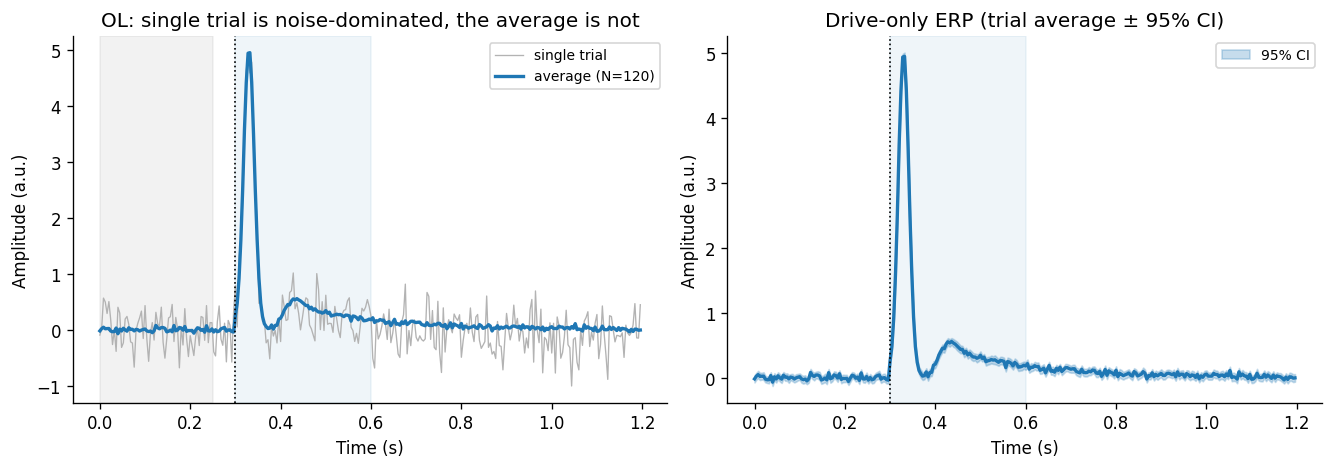

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

# Single trial vs. average: signal averaging reveals the ERP (Luck, 2014).
axes[0].plot(t, trials_drive[0, :, target_idx], color="0.7", lw=0.8, label="single trial")
axes[0].plot(t, erp_drive[:, target_idx], color="C0", lw=2.0, label=f"average (N={res_drive.n_trials})")
axes[0].axvspan(*BASELINE_WIN, color="k", alpha=0.05)
axes[0].axvspan(*COMPONENT_WIN, color="C0", alpha=0.07)
axes[0].axvline(ONSET_S, color="k", ls=":", lw=1)
axes[0].set_title(f"{TARGET}: single trial is noise-dominated, the average is not")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (a.u.)")
axes[0].legend(fontsize="small")

axes[1].plot(t, erp_drive[:, target_idx], color="C0", lw=2.0)
axes[1].fill_between(
    t,
    erp_drive[:, target_idx] - 1.96 * sem_drive[:, target_idx],
    erp_drive[:, target_idx] + 1.96 * sem_drive[:, target_idx],
    color="C0", alpha=0.25, label="95% CI",
)
axes[1].axvspan(*COMPONENT_WIN, color="C0", alpha=0.07)
axes[1].axvline(ONSET_S, color="k", ls=":", lw=1)
axes[1].set_title("Drive-only ERP (trial average ± 95% CI)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude (a.u.)")
axes[1].legend(fontsize="small")
plt.show()

## 5. Experiment B — connectivity modulation only

`ERPEvent` with a `StepModulation` and **no** drive. The modulation was
already shown (Section 3) to keep the companion spectral radius $<1$, so it is
a legal, stationary, deterministic schedule.

Per Section 3 the trial average must therefore stay at the noise floor while
the **across-trial variance** changes inside the modulation window — a
first-moment vs. second-moment dissociation.

In [8]:
event_mod = ERPEvent(onset_seconds=ONSET_S, drive=None, modulation=modulation, name="connectivity-only")

res_mod = simulate_trials(
    model, params, noise_fn,
    n_trials=N_TRIALS, events=[event_mod], regions=regions, rng=RNG_SEED,
)
trials_mod = baseline_correct_trials(res_mod.trials, params.sample_rate_hz, BASELINE_WIN)
erp_mod = trials_mod.mean(axis=0)
sem_mod = trials_mod.std(axis=0, ddof=1) / np.sqrt(res_mod.n_trials)
var_mod = trials_mod.var(axis=0, ddof=1)
var_drive_noise = baseline_correct_trials(
    simulate_trials(model, params, noise_fn, n_trials=N_TRIALS, rng=RNG_SEED).trials,
    params.sample_rate_hz, BASELINE_WIN,
).var(axis=0, ddof=1)

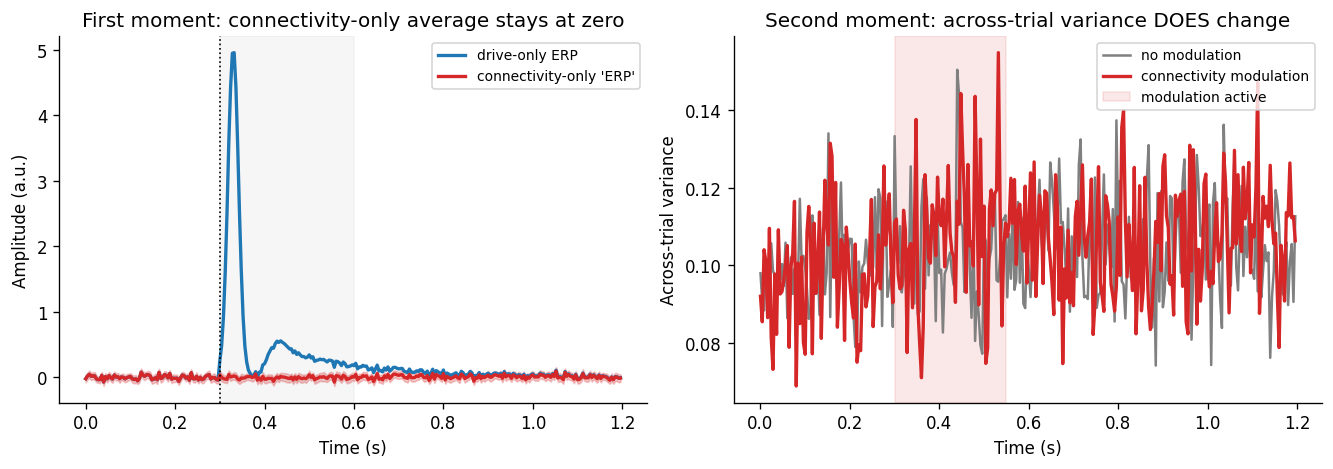

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(t, erp_drive[:, target_idx], color="C0", lw=2.0, label="drive-only ERP")
axes[0].plot(t, erp_mod[:, target_idx], color="C3", lw=2.0, label="connectivity-only 'ERP'")
axes[0].fill_between(
    t,
    erp_mod[:, target_idx] - 1.96 * sem_mod[:, target_idx],
    erp_mod[:, target_idx] + 1.96 * sem_mod[:, target_idx],
    color="C3", alpha=0.25,
)
axes[0].axvspan(*COMPONENT_WIN, color="0.5", alpha=0.07)
axes[0].axvline(ONSET_S, color="k", ls=":", lw=1)
axes[0].set_title("First moment: connectivity-only average stays at zero")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (a.u.)")
axes[0].legend(fontsize="small")

axes[1].plot(t, var_drive_noise[:, target_idx], color="0.5", lw=1.5, label="no modulation")
axes[1].plot(t, var_mod[:, target_idx], color="C3", lw=2.0, label="connectivity modulation")
axes[1].axvspan(ONSET_S, ONSET_S + modulation.duration_seconds, color="C3", alpha=0.10,
                label="modulation active")
axes[1].set_title("Second moment: across-trial variance DOES change")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Across-trial variance")
axes[1].legend(fontsize="small")
plt.show()

## 6. Experiment C — drive + connectivity modulation

Both knobs together. The **signed mean comes entirely from the drive**; the
concurrent connectivity modulation *gates* it. A subtlety the macroscopic
thesis predicts: the **early peak (~30 ms post-onset) is the direct sensory
volley — the injected pulse itself — and is therefore invariant to
connectivity** (a connectivity change cannot alter the input). What the
modulation gates is the **network-propagated component** that follows it
(the delayed long-range echo). We therefore quantify the effect in a *late*
sub-window (`(0.40, 0.60) s`), the network-shaped part — the model's mechanism
for state-/attention-dependent ERP-amplitude effects (e.g. P300 amplitude
scaling with attention/arousal; Polich, 2007).

direct-volley peak (0.30-0.60 s): drive=4.9553  drive+mod=4.9525  -> gain x1.00 (invariant: this is the input pulse, latency 0.332 s)
network component RMS (0.40-0.60 s): drive=0.3427  drive+mod=0.7948  -> gain x2.32 (connectivity modulation gates the propagated echo)


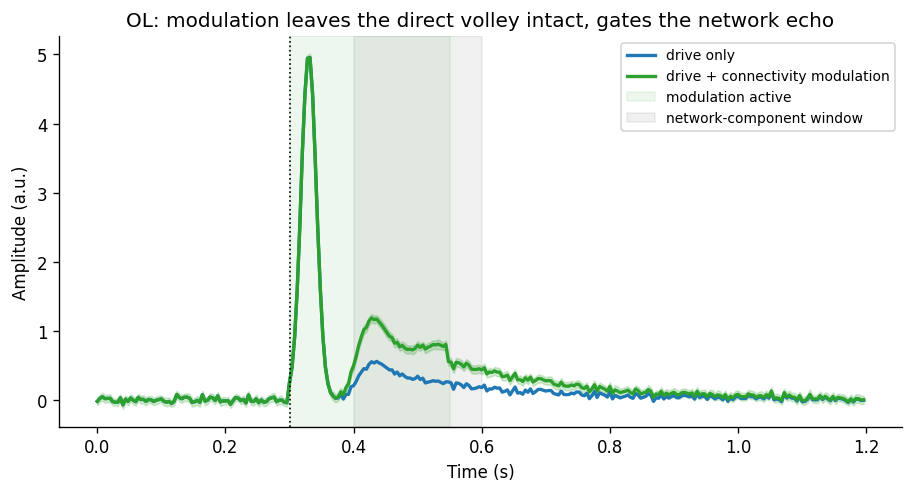

In [10]:
event_both = ERPEvent(onset_seconds=ONSET_S, drive=drive, modulation=modulation, name="drive+modulation")

res_both = simulate_trials(
    model, params, noise_fn,
    n_trials=N_TRIALS, events=[event_both], regions=regions, rng=RNG_SEED,
)
trials_both = baseline_correct_trials(res_both.trials, params.sample_rate_hz, BASELINE_WIN)
erp_both = trials_both.mean(axis=0)
sem_both = trials_both.std(axis=0, ddof=1) / np.sqrt(res_both.n_trials)

cs = int(round(COMPONENT_WIN[0] * params.sample_rate_hz))
ce = int(round(COMPONENT_WIN[1] * params.sample_rate_hz))
LATE_WIN = (0.40, 0.60)  # network-propagated component, after the direct volley
ls = int(round(LATE_WIN[0] * params.sample_rate_hz))
le = int(round(LATE_WIN[1] * params.sample_rate_hz))

amp_drive = peak_amplitude(erp_drive, COMPONENT_WIN, params.sample_rate_hz)[target_idx]
amp_both = peak_amplitude(erp_both, COMPONENT_WIN, params.sample_rate_hz)[target_idx]
lat_drive = peak_latency(erp_drive, COMPONENT_WIN, params.sample_rate_hz)[target_idx]
rms_drive = float(np.sqrt(np.mean(erp_drive[ls:le, target_idx] ** 2)))
rms_both = float(np.sqrt(np.mean(erp_both[ls:le, target_idx] ** 2)))

print(f"direct-volley peak (0.30-0.60 s): drive={amp_drive:.4f}  drive+mod={amp_both:.4f}  "
      f"-> gain x{amp_both / amp_drive:.2f} (invariant: this is the input pulse, latency {lat_drive:.3f} s)")
print(f"network component RMS (0.40-0.60 s): drive={rms_drive:.4f}  drive+mod={rms_both:.4f}  "
      f"-> gain x{rms_both / rms_drive:.2f} (connectivity modulation gates the propagated echo)")

fig, ax = plt.subplots(figsize=(7.5, 4.0), constrained_layout=True)
ax.plot(t, erp_drive[:, target_idx], color="C0", lw=2.0, label="drive only")
ax.plot(t, erp_both[:, target_idx], color="C2", lw=2.0, label="drive + connectivity modulation")
ax.fill_between(
    t,
    erp_both[:, target_idx] - 1.96 * sem_both[:, target_idx],
    erp_both[:, target_idx] + 1.96 * sem_both[:, target_idx],
    color="C2", alpha=0.20,
)
ax.axvspan(ONSET_S, ONSET_S + modulation.duration_seconds, color="C2", alpha=0.08,
           label="modulation active")
ax.axvspan(*LATE_WIN, color="k", alpha=0.06, label="network-component window")
ax.axvline(ONSET_S, color="k", ls=":", lw=1)
ax.set_title(f"{TARGET}: modulation leaves the direct volley intact, gates the network echo")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (a.u.)")
ax.legend(fontsize="small")
plt.show()

## 7. Convergence analysis: the decisive quantitative test

The cleanest discriminator follows directly from Section 3. As the number of
trials $N$ grows:

* **drive-only** — the trial-average peak converges to a **stable non-zero**
  value (deterministic component; bias does not average away);
* **connectivity-only** — the trial-average peak is pure sampling noise and
  **decays as $N^{-1/2}$ towards zero** (no first-moment component exists).

We plot the post-stimulus peak of $|\text{trial average}|$ at `OL` against $N$
on log–log axes, with an $N^{-1/2}$ reference line. The connectivity-only curve
tracking the reference slope, while the drive curve plateaus, *is* the proof
that connectivity changes cannot make an ERP.

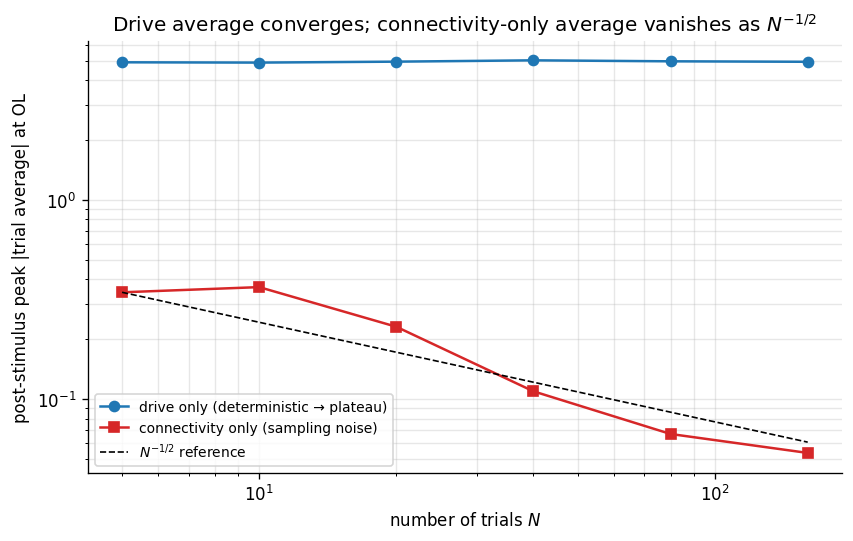

log-log slope  connectivity-only = -0.62  (theory: -0.50, pure 1/sqrt(N) decay)
log-log slope  drive-only        = +0.00  (theory:  0.00, deterministic plateau)


In [11]:
n_grid = [5, 10, 20, 40, 80, 160]
peak_drive, peak_mod = [], []

for n in n_grid:
    rd = simulate_trials(model, params, noise_fn, n_trials=n,
                         events=[event_drive], regions=regions, rng=RNG_SEED)
    rm = simulate_trials(model, params, noise_fn, n_trials=n,
                         events=[event_mod], regions=regions, rng=RNG_SEED)
    ad = baseline_correct_trials(rd.trials, params.sample_rate_hz, BASELINE_WIN).mean(axis=0)
    am = baseline_correct_trials(rm.trials, params.sample_rate_hz, BASELINE_WIN).mean(axis=0)
    peak_drive.append(np.max(np.abs(ad[cs:ce, target_idx])))
    peak_mod.append(np.max(np.abs(am[cs:ce, target_idx])))

peak_drive = np.array(peak_drive)
peak_mod = np.array(peak_mod)
n_arr = np.array(n_grid, dtype=float)
ref = peak_mod[0] * np.sqrt(n_arr[0] / n_arr)  # N^{-1/2} reference anchored at first point

fig, ax = plt.subplots(figsize=(7.0, 4.4), constrained_layout=True)
ax.loglog(n_arr, peak_drive, "o-", color="C0", label="drive only (deterministic → plateau)")
ax.loglog(n_arr, peak_mod, "s-", color="C3", label="connectivity only (sampling noise)")
ax.loglog(n_arr, ref, "k--", lw=1, label=r"$N^{-1/2}$ reference")
ax.set_xlabel("number of trials $N$")
ax.set_ylabel(f"post-stimulus peak |trial average| at {TARGET}")
ax.set_title("Drive average converges; connectivity-only average vanishes as $N^{-1/2}$")
ax.legend(fontsize="small")
ax.grid(which="both", alpha=0.3)
plt.show()

slope_mod = np.polyfit(np.log(n_arr), np.log(peak_mod), 1)[0]
slope_drive = np.polyfit(np.log(n_arr), np.log(peak_drive), 1)[0]
print(f"log-log slope  connectivity-only = {slope_mod:+.2f}  (theory: -0.50, pure 1/sqrt(N) decay)")
print(f"log-log slope  drive-only        = {slope_drive:+.2f}  (theory:  0.00, deterministic plateau)")

## 8. Statistical evaluation (mirroring the parent paper's procedure)

We test each condition for a **systematic signed deflection** with the *same*
decision rule the parent paper uses for its alpha-vs-control test (Section 2.5
of Steeghs-Turchina et al., 2025): for each trial form the contrast

$$D_i \;=\; \overline{h}_{\text{component}}^{(i)} \;-\;
            \overline{h}_{\text{baseline}}^{(i)}$$

at `OL`, test normality with **Shapiro–Wilk**, then apply a **one-sided paired
$t$-test** (mean) if normal, otherwise a **one-sided Wilcoxon signed-rank test**
(median). We report the effect size and a non-parametric bootstrap CI of the
mean ERP amplitude. A second-order **Levene test** checks the across-trial
variance change that connectivity modulation is expected to produce.

In [12]:
def trial_contrasts(trials_bc):
    """Per-trial (component-mean - baseline-mean) at the target region."""
    bs = int(round(BASELINE_WIN[0] * params.sample_rate_hz))
    be = int(round(BASELINE_WIN[1] * params.sample_rate_hz))
    base = trials_bc[:, bs:be, target_idx].mean(axis=1)
    comp = trials_bc[:, cs:ce, target_idx].mean(axis=1)
    return comp - base


def evaluate(name, trials_bc):
    d = trial_contrasts(trials_bc)
    sw_p = stats.shapiro(d).pvalue
    if sw_p >= 0.05:
        test, stat_p = "paired t (mean)", stats.ttest_1samp(d, 0.0, alternative="greater").pvalue
        center = float(np.mean(d))
    else:
        test, stat_p = "Wilcoxon (median)", stats.wilcoxon(d, alternative="greater").pvalue
        center = float(np.median(d))
    cohen_d = float(np.mean(d) / np.std(d, ddof=1))
    boot = stats.bootstrap((d,), np.mean, n_resamples=2000,
                           random_state=RNG_SEED).confidence_interval
    # Second-order: component vs baseline across-trial variance (Levene).
    bs = int(round(BASELINE_WIN[0] * params.sample_rate_hz))
    be = int(round(BASELINE_WIN[1] * params.sample_rate_hz))
    lev_p = stats.levene(trials_bc[:, cs:ce, target_idx].ravel(),
                          trials_bc[:, bs:be, target_idx].ravel()).pvalue
    print(f"{name:>22s} | SW p={sw_p:6.3f} -> {test:17s} "
          f"p={stat_p:7.4f} | center={center:+.4f} d={cohen_d:+.2f} "
          f"| meanCI=[{boot.low:+.4f},{boot.high:+.4f}] | Levene p={lev_p:.3g}")
    return stat_p


print("H1: component-window mean > baseline-window mean at OL (one-sided)\n" + "-" * 118)
p_drive = evaluate("drive only", trials_drive)
p_mod = evaluate("connectivity only", trials_mod)
p_both = evaluate("drive + modulation", trials_both)
print("-" * 118)
print("A signed ERP is present  iff  a drive is present:")
print(f"  drive-only          significant signed deflection : {p_drive < 0.05}")
print(f"  connectivity-only   significant signed deflection : {p_mod < 0.05}  <-- expected False")
print(f"  drive + modulation  significant signed deflection : {p_both < 0.05}")

H1: component-window mean > baseline-window mean at OL (one-sided)
----------------------------------------------------------------------------------------------------------------------
            drive only | SW p= 0.359 -> paired t (mean)   p= 0.0000 | center=+0.7221 d=+9.46 | meanCI=[+0.7081,+0.7355] | Levene p=1.76e-235
     connectivity only | SW p= 0.100 -> paired t (mean)   p= 0.7363 | center=-0.0053 d=-0.06 | meanCI=[-0.0222,+0.0107] | Levene p=5.37e-06
    drive + modulation | SW p= 0.100 -> paired t (mean)   p= 0.0000 | center=+1.0238 d=+11.10 | meanCI=[+1.0069,+1.0398] | Levene p=2.97e-304
----------------------------------------------------------------------------------------------------------------------
A signed ERP is present  iff  a drive is present:
  drive-only          significant signed deflection : True
  connectivity-only   significant signed deflection : False  <-- expected False
  drive + modulation  significant signed deflection : True


## 9. Discussion — what goes in the paper

**Main result.** In the macroscopic linear VAR of Steeghs-Turchina et al.
(2025), an ERP is the noise-expectation of the state. Because the noise is
zero-mean and the dynamics are linear and constrained to be stationary, that
expectation is **identically zero unless a deterministic additive drive
$z(w,t)$ is present** (Section 3). Connectivity modulation is a deterministic
*multiplicative* change of $\Phi$; it reshapes the **second-order** structure
(variance/power/coherence — Experiment B, Section 5) but can never create the
**first-order**, signed, time-locked deflection that *defines* a component such
as the P300 (Polich, 2007). The convergence analysis (Section 7) makes this
quantitative: the connectivity-only trial average decays as $N^{-1/2}$ — it is
pure sampling noise — while the drive average plateaus. **ERPs in this model
class require drives; connectivity changes can only gate them** (Experiment C).

**Why "ride the weights up/down" fails — the stationarity point.** A connectivity
excursion large or sustained enough to bias the mean would push the companion
spectral radius $\ge 1$ (non-stationary, unbounded variance), which the paper's
construction explicitly forbids and repairs via $\gamma\!\leftarrow\!0.9\gamma$
(Eqs. 24–25; Shumway & Stoffer, 2017). Within the permitted stationary regime,
$\Phi$ multiplies a *zero-mean* process, so the sign of the response on each
trial is set by the noise and averages out. There is no stationary, zero-mean,
linear route to a reproducible P300-shaped peak from connectivity alone.

**Relation to the ERP-genesis literature.** Whether ERPs arise from an additive
evoked response or from a stimulus-induced reorganisation of ongoing
oscillations (phase reset, amplitude change) is a long-standing debate
(Makeig et al., 2002, *Science* 295:690; Yeung, Bogacz, Holroyd & Cohen, 2004,
*Psychophysiology* 41:822; Sauseng et al., 2007, *Neuroscience* 146:1435). Our
analysis sharpens one side of it *for this model class*: a pure power/variance
change (the linear analogue of an amplitude/phase modulation of ongoing
activity) yields **no** signed average. A known route by which oscillatory
modulation *can* yield an evoked response is **amplitude asymmetry** of a
non-zero-mean / rectified signal (Mazaheri & Jensen, 2008, *J. Neurosci.*
28:7781; Nikulin et al., 2007). That mechanism is **excluded here by
construction**: the state is zero-mean and the read-out is linear, so amplitude
modulation is symmetric about zero and cannot shift the trial mean. This is
precisely why the planned **nonlinear extension** of the package
(`NonlinearVAR` with a `CentredSigmoid` transfer; Ramesh's draft / the paper's
"planned scientific extensions") is the natural next step: a saturating
non-linearity breaks the symmetry and would let connectivity modulation
contribute to the evoked mean — a concrete, falsifiable prediction this notebook
sets up.

**Statistics.** Using the parent paper's own Shapiro–Wilk → $t$/Wilcoxon
procedure (Section 2.5), only drive-containing conditions show a significant
one-sided signed deflection at `OL`; connectivity-only does not, while its
Levene test confirms the expected second-order (variance) change. ERP SNR grows
as $\sqrt{N}$ (Luck, 2014), so component detectability is a function of trial
count and background-noise scale, not of connectivity strength.

**Limitations / honest caveats.** (i) The conclusion is exact for the *linear,
zero-mean* model; it does **not** transfer to the nonlinear extension (above).
(ii) We used a reduced sampling rate / lag depth for interactivity; the
argument is rate-independent (it is about expectations and stationarity), but
final paper figures should use the paper's 1 kHz / 300-lag configuration.
(iii) Drive shape here is a generic Gaussian volley; mapping specific
components (P1/N1/P300) to specific regional drives and delays is future work.
(iv) Volume conduction and the white-vs-pink noise trade-off discussed in the
parent paper apply unchanged.

### References

- Steeghs-Turchina, Srinivasan, Nunez & Nunez (2025). Slow wave dynamics of
  scalp EEG can be explained by simple statistical models of long-range
  connections. *NeuroImage* **321**, 121418.
- Luck (2014). *An Introduction to the Event-Related Potential Technique*
  (2nd ed.). MIT Press. — ERP = signal averaging; SNR $\propto\sqrt{N}$.
- Polich (2007). Updating P300: an integrative theory of P3a and P3b.
  *Clinical Neurophysiology* **118**, 2128–2148.
- Makeig, Westerfield, Jung, et al. (2002). Dynamic brain sources of visual
  evoked responses. *Science* **295**, 690–694.
- Yeung, Bogacz, Holroyd & Cohen (2004). Detection of synchronized
  oscillations in the electroencephalogram. *Psychophysiology* **41**, 822–832.
- Sauseng, Klimesch, Gruber, et al. (2007). Are event-related potential
  components generated by phase resetting of brain oscillations?
  *Neuroscience* **146**, 1435–1444.
- Mazaheri & Jensen (2008). Asymmetric amplitude modulations of brain
  oscillations generate slow evoked responses. *J. Neuroscience* **28**,
  7781–7787.
- Shumway & Stoffer (2017). *Time Series Analysis and Its Applications*
  (4th ed.). Springer. — VAR stationarity / companion eigenvalues.
- Nunez & Srinivasan (2006). *Electric Fields of the Brain* (2nd ed.). OUP.